In [1]:
import rasterio

dem = rasterio.open("../data/raw/output_SRTMGL1.tif")   

print(dem.crs)
print(dem.bounds)
print(dem.shape)
print(dem.res)

EPSG:4326
BoundingBox(left=73.73180555558918, bottom=18.38569444443893, right=74.0181944444781, top=18.62208333332785)
(851, 1031)
(0.0002777777777778146, 0.0002777777777778146)


In [2]:
band1 = dem.read(1)
print(band1.min(), band1.max(), band1.mean())

516 1137 629.8548201978388


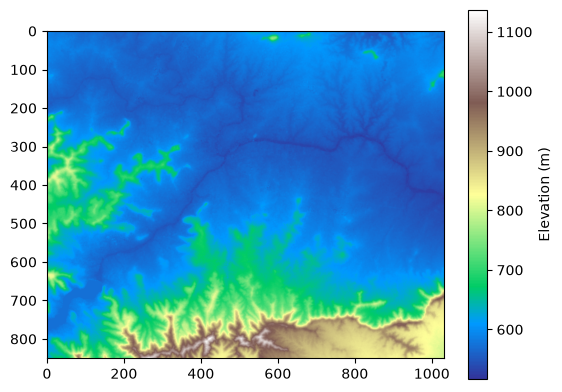

In [3]:
import matplotlib.pyplot as plt

plt.imshow(band1, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.show()

In [4]:
print(dem.nodata)

-32768.0


In [5]:
import rasterio

dem = rasterio.open("../data/raw/output_SRTMGL1_v2.tif")   

print(dem.crs)
print(dem.bounds)
print(dem.shape)
print(dem.res)

EPSG:4326
BoundingBox(left=73.4998611111447, bottom=18.38013888888338, right=74.01986111114476, top=18.62013888888341)
(864, 1872)
(0.0002777777777778146, 0.0002777777777778146)


In [6]:
band1 = dem.read(1)
print(band1.min(), band1.max(), band1.mean())

516 1199 668.706547142094


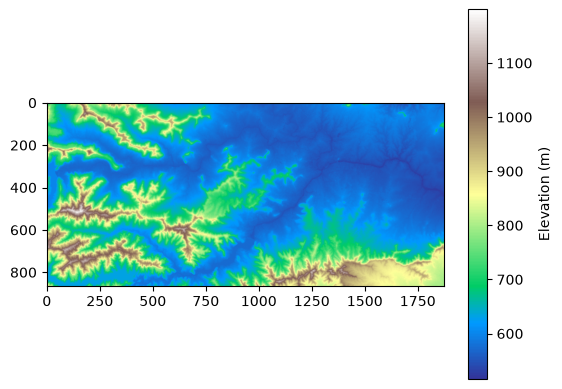

In [7]:
import matplotlib.pyplot as plt

plt.imshow(band1, cmap="terrain")
plt.colorbar(label="Elevation (m)")
plt.show()

In [8]:
print(dem.nodata)

-32768.0


In [9]:
pip install rasterstats


   ---------------------------------------- 0/3 [simplejson]
   ---------------------------------------- 0/3 [simplejson]
   ---------------------------------------- 0/3 [simplejson]
   -------------------------- ------------- 2/3 [rasterstats]
   ---------------------------------------- 3/3 [rasterstats]

Note: you may need to restart the kernel to use updated packages.


In [11]:
import geopandas as gpd

wards = gpd.read_file("../data/raw/pune_wards.geojson")

In [12]:
from rasterstats import zonal_stats

stats = zonal_stats(wards, "../data/raw/output_SRTMGL1_v2.tif", stats=["mean", "min", "max"])